2026-05-07 13:01:31.421192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778158891.447267     339 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778158891.455643     339 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778158891.474832     339 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778158891.474855     339 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778158891.474858     339 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
Running on Kaggle — outputs will be saved to /kaggle/working/
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


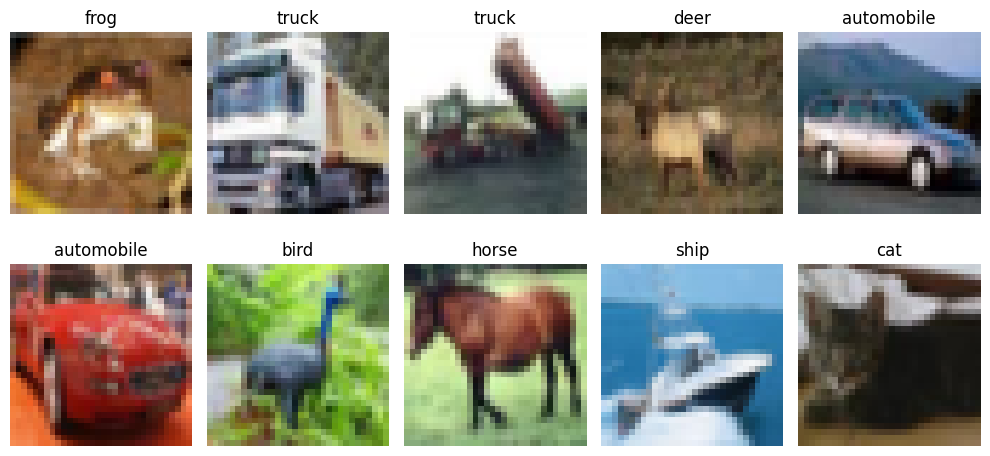

Resizing images to 96x96...


I0000 00:00:1778158904.062252     339 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train ResNet data ready.
Test ResNet data ready.

APPROACH 1: ResNet50 + SVM
Extracting features...


I0000 00:00:1778158939.275601     403 service.cc:152] XLA service 0x7d38e406afc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778158939.275636     403 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778158940.069606     403 cuda_dnn.cc:529] Loaded cuDNN version 91002


   8/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step

I0000 00:00:1778158942.529312     403 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Train Features Shape: (50000, 2048)
Test Features Shape: (10000, 2048)

[SVM] Using 10000 / 50000 samples (20%) for training.

Training SVM...

===== SVM RESULTS =====
Accuracy : 0.8256
Precision: 0.8273
Recall   : 0.8256
F1-Score : 0.8261

Classification Report:

              precision    recall  f1-score   support

    airplane       0.82      0.88      0.85      1000
  automobile       0.90      0.88      0.89      1000
        bird       0.78      0.83      0.80      1000
         cat       0.68      0.71      0.69      1000
        deer       0.79      0.78      0.78      1000
         dog       0.77      0.74      0.76      1000
        frog       0.88      0.86      0.87      1000
       horse       0.88      0.82      0.85      1000
        ship       0.90      0.90      0.90      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.83     1000

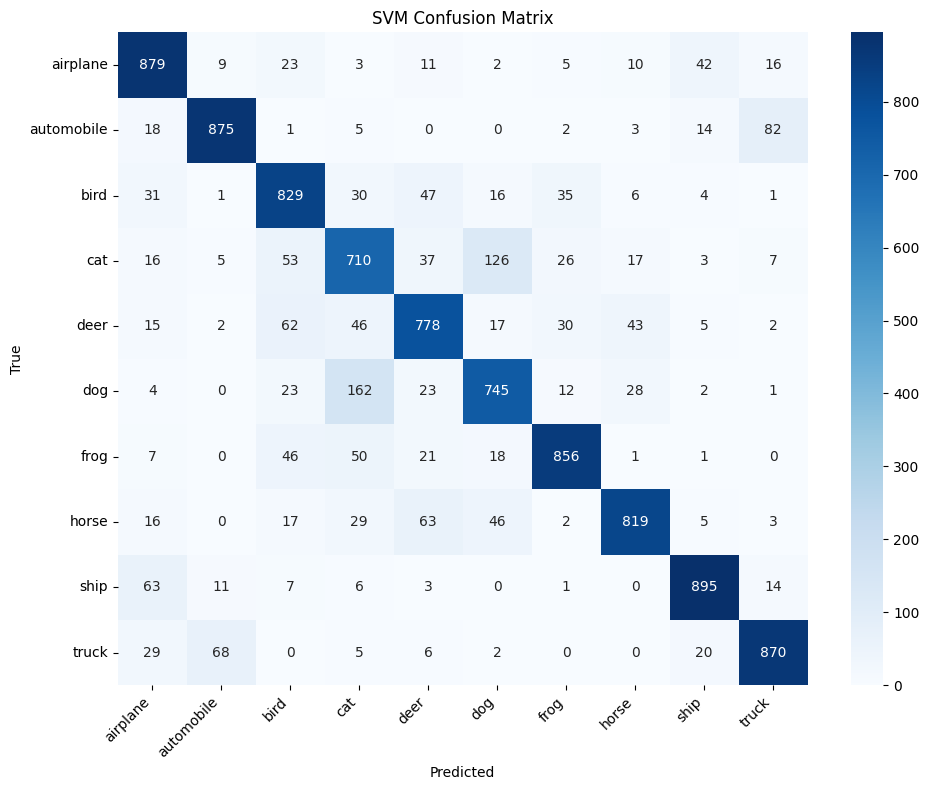

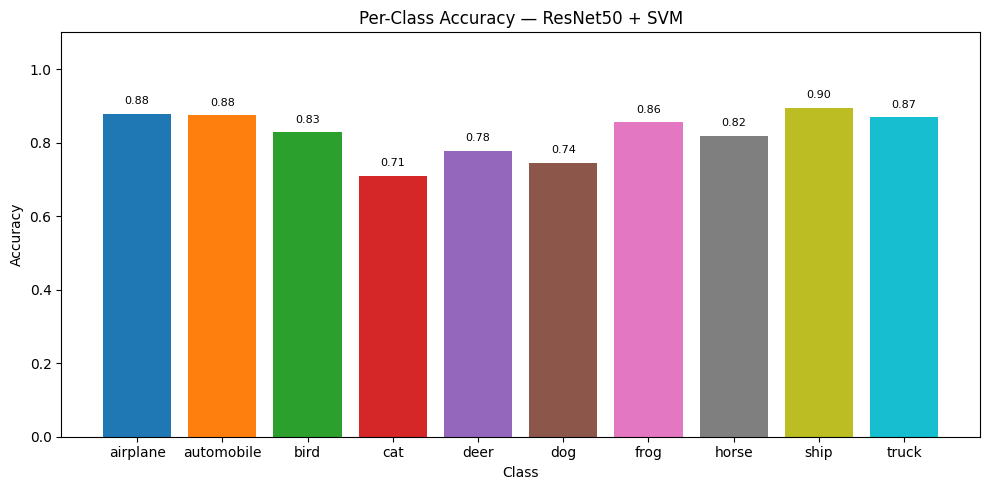


APPROACH 2: End-to-End ResNet50


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,018 (92.02 MB)

 Trainable params: 531,210 (2.03 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


--- Phase 1: Training with frozen ResNet50 base ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5350 - loss: 1.5728
Epoch 1: val_accuracy improved from -inf to 0.82460, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 86ms/step - accuracy: 0.5351 - loss: 1.5725 - val_accuracy: 0.8246 - val_loss: 0.5203 - learning_rate: 1.0000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7278 - loss: 0.8516
Epoch 2: val_accuracy improved from 0.82460 to 0.84000, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.7278 - loss: 0.8516 - val_accuracy: 0.8400 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7489 - loss: 0.7547
Epoch 3: val_accuracy improved from 0.84000 to 0.84370, saving model to /kaggle/working/best_resnet50_phase1.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 117s 75ms/step - accuracy: 0.7489 - loss: 0.7547 - val_accuracy: 0.8437 -

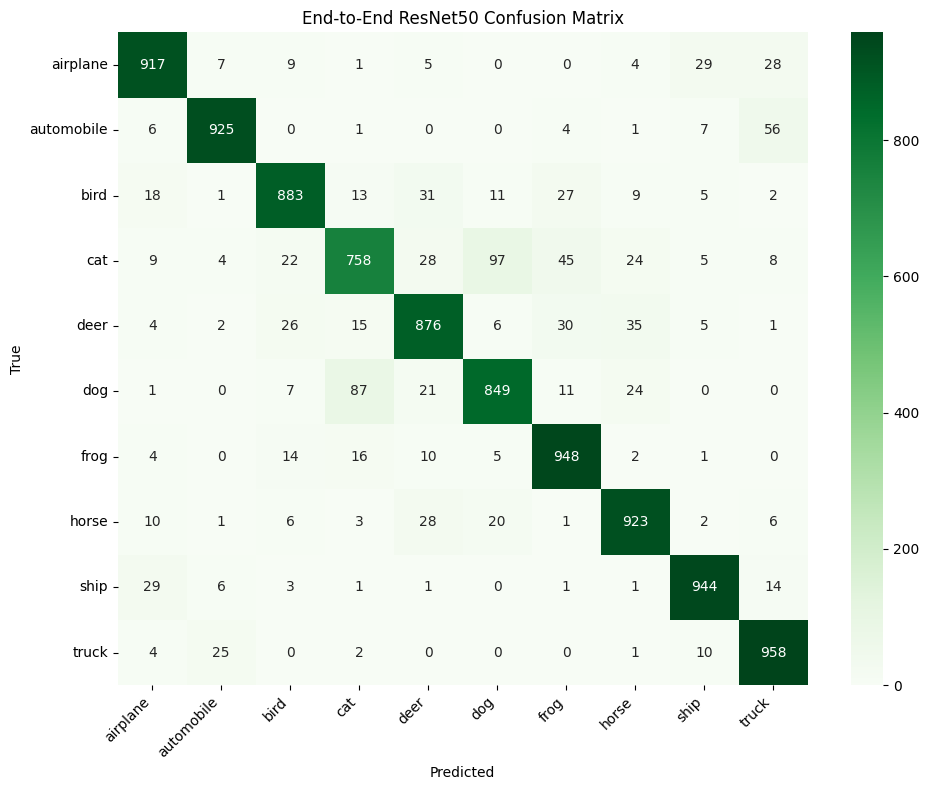

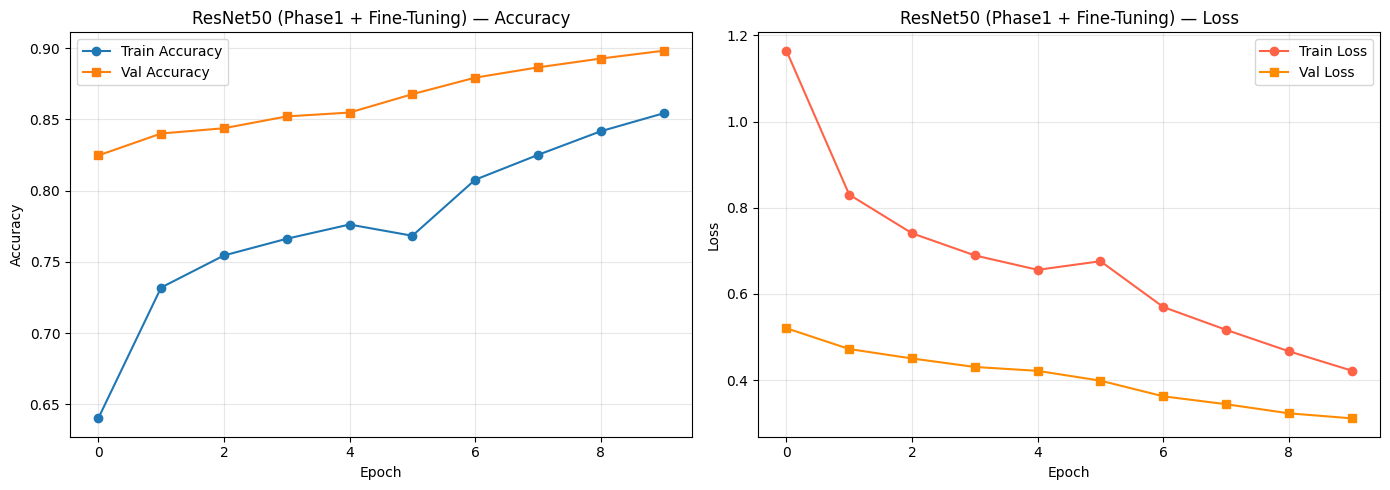

Fine-tuning started at epoch 6


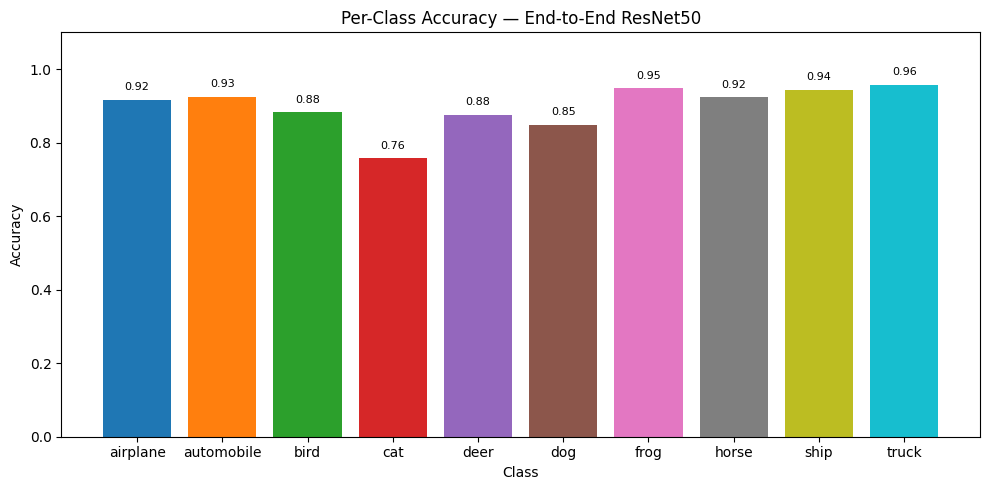


BONUS MODEL: MobileNetV2
Freed ResNet arrays. Re-resizing for MobileNetV2...
MobileNetV2 data ready.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5921 - loss: 1.2752
Epoch 1: val_accuracy improved from -inf to 0.83530, saving model to /kaggle/working/best_mobilenetv2.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.5921 - loss: 1.2750 - val_accuracy: 0.8353 - val_loss: 0.4827 - learning_rate: 1.0000e-04
Epoch 2/5
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8124 - loss: 0.5540
Epoch 2: val_accuracy improved from 0.83530 to 0.85160, saving model to /kaggle/working/best_mobilenetv2.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8124 - loss: 0.5539 - val_accuracy: 0.8516 - val_loss: 0.4322 - learning_rate: 1.0000e-04
Epoch 3/5
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8395 - loss: 0.4683
Epoch 3: val_accuracy improved from 0.85160 to 0.85590, saving model t

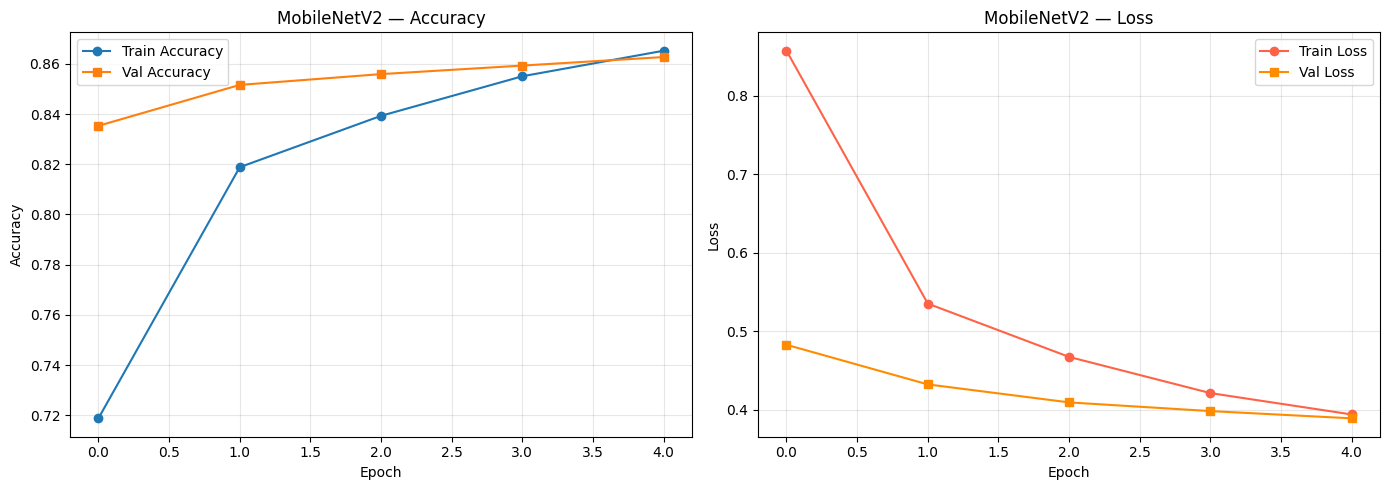

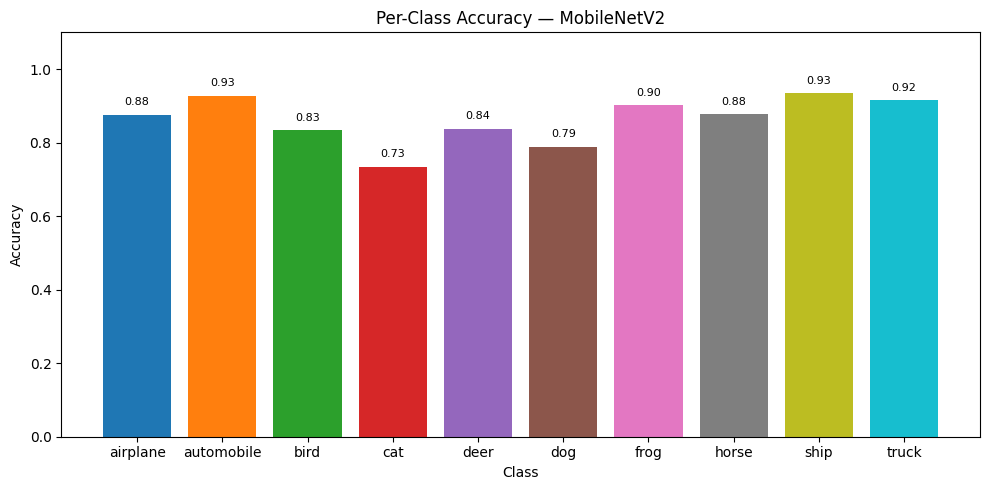

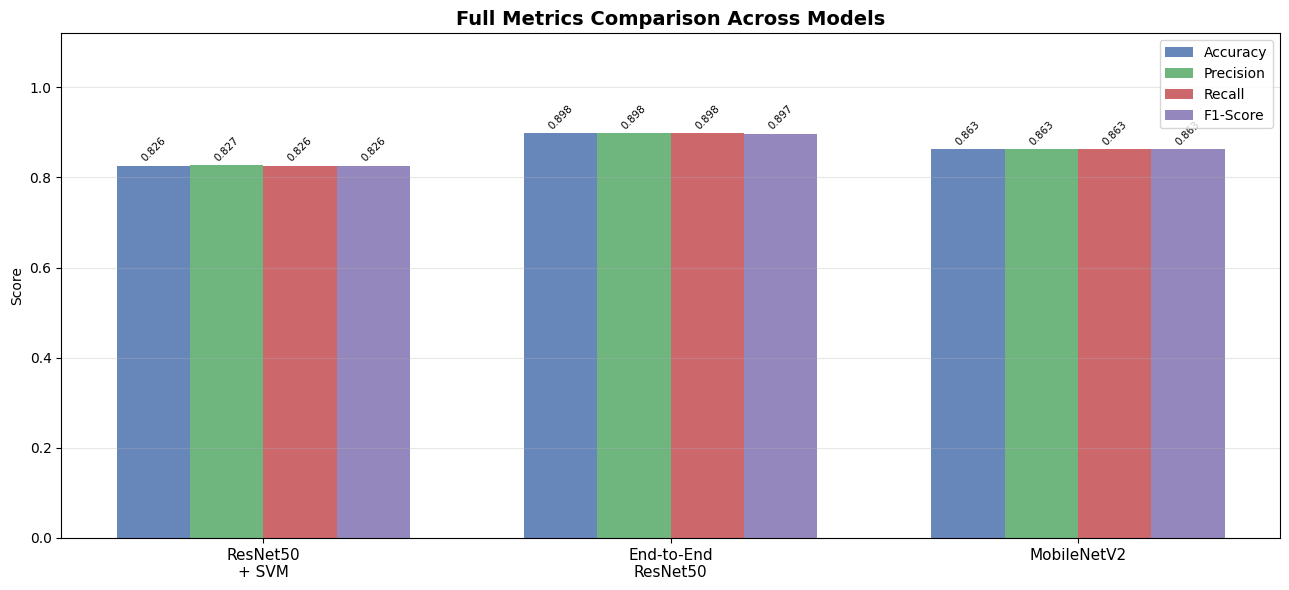


FINAL COMPARISON
Model                           Accuracy  Precision   Recall       F1
---------------------------------------------------------------------
ResNet50 + SVM                    0.8256     0.8273   0.8256   0.8261
End-to-End ResNet50               0.8981     0.8978   0.8981   0.8974
MobileNetV2                       0.8627     0.8626   0.8627   0.8626

Project Completed Successfully.


In [1]:
# =========================================================
# Deep Learning Project
# CIFAR-10 Classification
# Approach 1:
#   ResNet50 Feature Extractor + SVM
#
# Approach 2:
#   End-to-End ResNet50 (with Fine-Tuning phase)
#
# Bonus:
#   Extra CNN Model = MobileNetV2
#
# Modifications Added:
#   - SVM subset sampling (faster training)
#   - EarlyStopping + ReduceLROnPlateau callbacks
#   - Fine-Tuning phase for ResNet50 (last 30 layers)
#   - Loss curves alongside accuracy curves
#   - Full metrics comparison chart (Acc/Prec/Recall/F1)
#   - Model checkpointing (best weights)
#   - Per-class accuracy bar charts
#
# Platform:
#   Google Colab / Kaggle
# =========================================================

# =========================================================
# INSTALL / IMPORT LIBRARIES
# =========================================================

import os
import gc

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler

print("TensorFlow Version:", tf.__version__)

# =========================================================
# CONFIGURATION
# =========================================================

# --- Kaggle / Colab auto-detection ---
# On Kaggle, outputs must go to /kaggle/working/
# On Colab or local, outputs go to the current directory.
if os.path.exists('/kaggle/working'):
    OUTPUT_DIR = '/kaggle/working/'
    print("Running on Kaggle — outputs will be saved to /kaggle/working/")
else:
    OUTPUT_DIR = './'
    print("Running on Colab / Local — outputs will be saved to current directory")

# [MODIFICATION] Fraction of training data used for SVM
# (1.0 = full 50k samples, 0.2 = 10k samples for speed)
SVM_SAMPLE_FRACTION = 0.2

# [OOM FIX] Reduced from 224 to 96 to fit in Kaggle's 13 GB RAM.
# Memory usage: 96x96 = ~2.5 GB vs 224x224 = ~36 GB for 60k images.
# ResNet50/MobileNetV2 work well from 32x32 upwards.
IMG_SIZE = 96
EPOCHS_PHASE1 = 5   # frozen base
EPOCHS_PHASE2 = 5   # fine-tuning (ResNet50 only)
BATCH_SIZE = 32

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# =========================================================
# LOAD CIFAR-10 DATASET
# =========================================================

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

# =========================================================
# VISUALIZE SAMPLE IMAGES
# =========================================================

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=100, bbox_inches='tight')
plt.show()

# =========================================================
# RESIZE IMAGES FOR PRETRAINED CNNs
# =========================================================

def resize_images(images):
    resized = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    return resized.numpy()

print(f"Resizing images to {IMG_SIZE}x{IMG_SIZE}...")

# =========================================================
# NORMALIZATION + MEMORY-EFFICIENT LOADING
# [OOM FIX] Resize → preprocess → immediately delete the raw
# resized array so we never hold two full float32 copies at once.
# =========================================================

x_train_resnet = resnet_preprocess(resize_images(x_train))
print("Train ResNet data ready.")
gc.collect()

x_test_resnet = resnet_preprocess(resize_images(x_test))
print("Test ResNet data ready.")
gc.collect()

# =========================================================
# DATA AUGMENTATION
# =========================================================

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
train_datagen.fit(x_train_resnet)

# =========================================================
# ONE HOT ENCODING
# =========================================================

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


# =========================================================
# HELPER: Plot Training Curves (Accuracy + Loss)
# =========================================================

def plot_training_curves(history, title_prefix, save_name):
    """[MODIFICATION] Plot both accuracy and loss curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
    axes[0].set_title(f"{title_prefix} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='tomato')
    axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s', color='darkorange')
    axes[1].set_title(f"{title_prefix} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=100, bbox_inches='tight')
    plt.show()


# =========================================================
# HELPER: Per-Class Accuracy Bar Chart
# =========================================================

def plot_per_class_accuracy(y_true, y_pred, model_name, save_name):
    """[MODIFICATION] Bar chart of per-class accuracy for each model."""
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    plt.figure(figsize=(10, 5))
    bars = plt.bar(class_names, per_class_acc, color=plt.cm.tab10.colors)
    plt.title(f"Per-Class Accuracy — {model_name}")
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    for bar, acc in zip(bars, per_class_acc):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}",
            ha='center', va='bottom', fontsize=8
        )
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=100, bbox_inches='tight')
    plt.show()


# =========================================================
# =========================================================
# APPROACH 1
# FEATURE EXTRACTION + SVM
# =========================================================
# =========================================================

print("\n==============================")
print("APPROACH 1: ResNet50 + SVM")
print("==============================")

# =========================================================
# LOAD PRETRAINED RESNET50 (Feature Extractor)
# =========================================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)
feature_extractor.trainable = False

print("Extracting features...")

# =========================================================
# FEATURE EXTRACTION
# =========================================================

train_features = feature_extractor.predict(x_train_resnet, batch_size=BATCH_SIZE, verbose=1)
test_features = feature_extractor.predict(x_test_resnet, batch_size=BATCH_SIZE, verbose=1)

print("Train Features Shape:", train_features.shape)
print("Test Features Shape:", test_features.shape)

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

# =========================================================
# [MODIFICATION] SUBSET SAMPLING FOR SVM
# Training SVM on all 50k samples is very slow.
# We randomly sample SVM_SAMPLE_FRACTION of the training set.
# =========================================================

np.random.seed(42)
n_samples = int(len(train_features_scaled) * SVM_SAMPLE_FRACTION)
subset_idx = np.random.choice(len(train_features_scaled), n_samples, replace=False)

train_features_svm = train_features_scaled[subset_idx]
y_train_svm = y_train.ravel()[subset_idx]

print(f"\n[SVM] Using {n_samples} / {len(train_features_scaled)} samples "
      f"({SVM_SAMPLE_FRACTION*100:.0f}%) for training.")

# =========================================================
# TRAIN SVM
# =========================================================

print("\nTraining SVM...")
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(train_features_svm, y_train_svm)

# =========================================================
# PREDICTIONS & EVALUATION
# =========================================================

svm_predictions = svm_model.predict(test_features_scaled)

svm_accuracy  = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average='weighted')
svm_recall    = recall_score(y_test, svm_predictions, average='weighted')
svm_f1        = f1_score(y_test, svm_predictions, average='weighted')

print("\n===== SVM RESULTS =====")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, svm_predictions, target_names=class_names))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'svm_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, svm_predictions, "ResNet50 + SVM", "svm_per_class.png")


# =========================================================
# =========================================================
# APPROACH 2
# END-TO-END RESNET50  (Phase 1: Frozen + Phase 2: Fine-Tuning)
# =========================================================
# =========================================================

print("\n==============================")
print("APPROACH 2: End-to-End ResNet50")
print("==============================")

# =========================================================
# BUILD MODEL
# =========================================================

base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model2.trainable = False

model = Sequential([
    base_model2,
    GlobalAveragePooling2D(),
    BatchNormalization(),          # [MODIFICATION] BN before dense
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# =========================================================
# [MODIFICATION] CALLBACKS
# =========================================================

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_resnet50_phase1.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# =========================================================
# PHASE 1: TRAIN WITH FROZEN BASE
# =========================================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n--- Phase 1: Training with frozen ResNet50 base ---")
history_p1 = model.fit(
    train_datagen.flow(x_train_resnet, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(x_test_resnet, y_test_cat),
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

# =========================================================
# [MODIFICATION] PHASE 2: FINE-TUNING
# Unfreeze the last 30 layers of ResNet50 and train with
# a much lower learning rate.
# =========================================================

print("\n--- Phase 2: Fine-Tuning last 30 layers of ResNet50 ---")

base_model2.trainable = True
for layer in base_model2.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_resnet50_finetuned.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_p2 = model.fit(
    train_datagen.flow(x_train_resnet, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(x_test_resnet, y_test_cat),
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

# =========================================================
# EVALUATION
# =========================================================

loss, accuracy = model.evaluate(x_test_resnet, y_test_cat)

predictions = model.predict(x_test_resnet)
predicted_classes = np.argmax(predictions, axis=1)

dl_precision = precision_score(y_test, predicted_classes, average='weighted')
dl_recall    = recall_score(y_test, predicted_classes, average='weighted')
dl_f1        = f1_score(y_test, predicted_classes, average='weighted')

print("\n===== END-TO-END ResNet50 RESULTS =====")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision    : {dl_precision:.4f}")
print(f"Recall       : {dl_recall:.4f}")
print(f"F1-Score     : {dl_f1:.4f}")

# Confusion Matrix
cm_dl = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("End-to-End ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet50_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# [MODIFICATION] Combined training curves (Phase 1 + Phase 2)
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return type('History', (), {'history': merged})()

combined_history = merge_histories(history_p1, history_p2)
plot_training_curves(combined_history, "ResNet50 (Phase1 + Fine-Tuning)", "resnet50_curves.png")

# Add a vertical line to show where fine-tuning starts
epochs_p1 = len(history_p1.history['accuracy'])
print(f"Fine-tuning started at epoch {epochs_p1 + 1}")

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, predicted_classes, "End-to-End ResNet50", "resnet50_per_class.png")


# =========================================================
# BONUS MODEL
# MobileNetV2
# =========================================================

print("\n==============================")
print("BONUS MODEL: MobileNetV2")
print("==============================")

# [OOM FIX] Free the ResNet preprocessed arrays before creating
# MobileNetV2 data — we re-resize from the original uint8 x_train
# (only ~150 MB) so peak memory stays low.
del x_train_resnet, x_test_resnet
gc.collect()
print("Freed ResNet arrays. Re-resizing for MobileNetV2...")

x_train_mobile = mobile_preprocess(resize_images(x_train))
gc.collect()
x_test_mobile = mobile_preprocess(resize_images(x_test))
gc.collect()
print("MobileNetV2 data ready.")

mobile_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mobile_base.trainable = False

mobile_model = Sequential([
    mobile_base,
    GlobalAveragePooling2D(),
    BatchNormalization(),           # [MODIFICATION] BN added
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mobile_model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# [MODIFICATION] Callbacks for MobileNetV2
callbacks_mobile = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_mobilenetv2.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

mobile_history = mobile_model.fit(
    x_train_mobile,
    y_train_cat,
    validation_data=(x_test_mobile, y_test_cat),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_mobile
)

mobile_loss, mobile_acc = mobile_model.evaluate(x_test_mobile, y_test_cat)

mobile_preds = np.argmax(mobile_model.predict(x_test_mobile), axis=1)
mob_precision = precision_score(y_test, mobile_preds, average='weighted')
mob_recall    = recall_score(y_test, mobile_preds, average='weighted')
mob_f1        = f1_score(y_test, mobile_preds, average='weighted')

print("\n===== MobileNetV2 RESULTS =====")
print(f"Accuracy : {mobile_acc:.4f}")
print(f"Precision: {mob_precision:.4f}")
print(f"Recall   : {mob_recall:.4f}")
print(f"F1-Score : {mob_f1:.4f}")

# [MODIFICATION] Training curves for MobileNetV2
plot_training_curves(mobile_history, "MobileNetV2", "mobilenet_curves.png")

# [MODIFICATION] Per-class accuracy chart
plot_per_class_accuracy(y_test, mobile_preds, "MobileNetV2", "mobilenet_per_class.png")


# =========================================================
# [MODIFICATION] FULL METRICS COMPARISON CHART
# Shows Accuracy, Precision, Recall, F1 side by side
# =========================================================

model_names = ['ResNet50\n+ SVM', 'End-to-End\nResNet50', 'MobileNetV2']

metrics = {
    'Accuracy' : [svm_accuracy,  accuracy,     mobile_acc],
    'Precision': [svm_precision, dl_precision, mob_precision],
    'Recall'   : [svm_recall,    dl_recall,    mob_recall],
    'F1-Score' : [svm_f1,        dl_f1,        mob_f1],
}

x_pos = np.arange(len(model_names))
width = 0.18
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric_name, values) in enumerate(metrics.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x_pos + offset, values, width, label=metric_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=7.5, rotation=45
        )

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Full Metrics Comparison Across Models", fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'full_metrics_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "="*50)
print("FINAL COMPARISON")
print("="*50)

header = f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}"
print(header)
print("-" * len(header))
print(f"{'ResNet50 + SVM':<30} {svm_accuracy:>9.4f} {svm_precision:>10.4f} {svm_recall:>8.4f} {svm_f1:>8.4f}")
print(f"{'End-to-End ResNet50':<30} {accuracy:>9.4f} {dl_precision:>10.4f} {dl_recall:>8.4f} {dl_f1:>8.4f}")
print(f"{'MobileNetV2':<30} {mobile_acc:>9.4f} {mob_precision:>10.4f} {mob_recall:>8.4f} {mob_f1:>8.4f}")

print("\nProject Completed Successfully.")


In [2]:
import shutil

shutil.make_archive(
    '/kaggle/working/myfiles',
    'zip',
    '/kaggle/working'
)

OSError: [Errno 28] No space left on device